In [1]:
# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load the RCB data

In [4]:
rcb_matches = pd.read_csv(r"H:\project1\rcb_clean.csv")
deliveries = pd.read_csv(r"H:\project1\deliveries.csv")
My_team = "Royal Challengers Bengaluru"

print(f"RCB matches loaded: {rcb_matches.shape[0]}rows")
print(rcb_matches.head(5))

RCB matches loaded: 255rows
   Unnamed: 0      id   season       city        date match_type  \
0           0  335982  2007/08  Bangalore  2008-04-18     League   
1           3  335985  2007/08     Mumbai  2008-04-20     League   
2          10  335992  2007/08  Bangalore  2008-04-26     League   
3          14  335996  2007/08  Bangalore  2008-04-28     League   
4          16  335998  2007/08      Delhi  2008-04-30     League   

  player_of_match                  venue                        team1  \
0     BB McCullum  M Chinnaswamy Stadium  Royal Challengers Bengaluru   
1      MV Boucher       Wankhede Stadium               Mumbai Indians   
2       SR Watson  M Chinnaswamy Stadium  Royal Challengers Bengaluru   
3        MS Dhoni  M Chinnaswamy Stadium  Royal Challengers Bengaluru   
4      GD McGrath       Feroz Shah Kotla             Delhi Daredevils   

                         team2  ... toss_decision  \
0        Kolkata Knight Riders  ...         field   
1  Royal Challenge

In [5]:
# FIX INCONSISTENT TEAM NAME

In [6]:
deliveries[['batting_team','bowling_team']] = deliveries[['batting_team','bowling_team']].replace({
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
})

deliveries.head(10)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
5,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,6,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
6,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,7,BB McCullum,P Kumar,SC Ganguly,0,1,1,legbyes,0,NaN,NaN,NaN
7,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,1,1,BB McCullum,Z Khan,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
8,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,1,2,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN
9,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,1,3,BB McCullum,Z Khan,SC Ganguly,4,0,4,NaN,0,NaN,NaN,NaN


In [7]:
# SEPARATRE RCB BOWLING DATA

In [8]:
x = deliveries[deliveries['bowling_team'] == My_team]
print(f"rcb bowling deliveries: {x.shape[0]} rows")

rcb bowling deliveries: 30159 rows


In [9]:
# SEPARATRE RCB BATTING DATA

In [10]:
y = deliveries[deliveries['batting_team'] == My_team]
print(f"rcb batting deliveries: {y.shape[0]} rows")

rcb batting deliveries: 30023 rows


In [11]:
# CREATE WIN/LOSS LOOKUP DICTIONARY

In [12]:
win_loss_dict = rcb_matches.set_index('id')['winner'].apply(lambda x: x == My_team).to_dict()

print(list(win_loss_dict.items())[:5])

[(335982, False), (335985, True), (335992, False), (335996, False), (335998, False)]


In [13]:
# TAG EACH DELIVERY AS WIN OR LOSS

In [14]:
y['rcb_won'] = y['match_id'].map(win_loss_dict)
x['rcb_won'] = x['match_id'].map(win_loss_dict)

#CHECK
print(y[['match_id', 'batter', 'batsman_runs', 'rcb_won']].head(5))

     match_id    batter  batsman_runs  rcb_won
124    335982  R Dravid             1    False
125    335982  W Jaffer             0    False
126    335982  W Jaffer             0    False
127    335982  W Jaffer             1    False
128    335982  R Dravid             1    False


In [15]:
# TOP 10 BATSMEN: RUNS IN WINS vs LOSSES

In [16]:
# Group by batter and win/loss, sum runs
batter_runs = y.groupby(['batter', 'rcb_won'])['batsman_runs'].sum().unstack(fill_value=0)

# Rename columns
batter_runs.columns = ['Runs_in_Losses', 'Runs_in_Wins']

# Total runs and % in wins
batter_runs['Total_Runs'] = batter_runs['Runs_in_Wins'] + batter_runs['Runs_in_Losses']
batter_runs['Pct_in_Wins'] = (batter_runs['Runs_in_Wins'] / batter_runs['Total_Runs'] * 100).round(1)

# Sort and take top 10
top_batsmen = batter_runs.sort_values('Total_Runs', ascending=False).head(10)
print(top_batsmen)

                Runs_in_Losses  Runs_in_Wins  Total_Runs  Pct_in_Wins
batter                                                               
V Kohli                   3736          4278        8014         53.4
AB de Villiers            1894          2616        4510         58.0
CH Gayle                   872          2303        3175         72.5
F du Plessis               731           905        1636         55.3
GJ Maxwell                 481           785        1266         62.0
JH Kallis                  588           544        1132         48.1
KD Karthik                 543           394         937         42.0
R Dravid                   482           416         898         46.3
D Padikkal                 370           514         884         58.1
RM Patidar                 360           439         799         54.9


In [17]:
# TOP 10 BOWLERS: WICKETS IN WINS vs LOSSES

In [18]:
# Group by bowler and win/loss, sum wickets
bowler_wickets = x.groupby(['bowler','rcb_won'])['is_wicket'].sum().unstack()
bowler_wickets.columns = ['wickets_in_Losses','wickets_in_Wins']

# Calculate totals and percentages
bowler_wickets['total_wickets'] = bowler_wickets['wickets_in_Losses'] + bowler_wickets['wickets_in_Wins']
bowler_wickets['Pct_in_Wins'] = (bowler_wickets['wickets_in_Wins'] / bowler_wickets['total_wickets'] * 100)

# Sort and take top 10
top_bowlers = bowler_wickets.sort_values('total_wickets',ascending = False).head(10)
print(top_bowlers)

                wickets_in_Losses  wickets_in_Wins  total_wickets  Pct_in_Wins
bowler                                                                        
YS Chahal                    73.0             70.0          143.0    48.951049
HV Patel                     37.0             71.0          108.0    65.740741
Mohammed Siraj               40.0             46.0           86.0    53.488372
R Vinay Kumar                29.0             54.0           83.0    65.060241
Z Khan                       26.0             30.0           56.0    53.571429
A Kumble                     16.0             33.0           49.0    67.346939
S Aravind                    13.0             35.0           48.0    72.916667
P Kumar                      13.0             27.0           40.0    67.500000
MA Starc                     16.0             23.0           39.0    58.974359
DW Steyn                     19.0             19.0           38.0    50.000000


In [19]:
# VISUALIZATION: TOP BATSMEN & BOWLERS

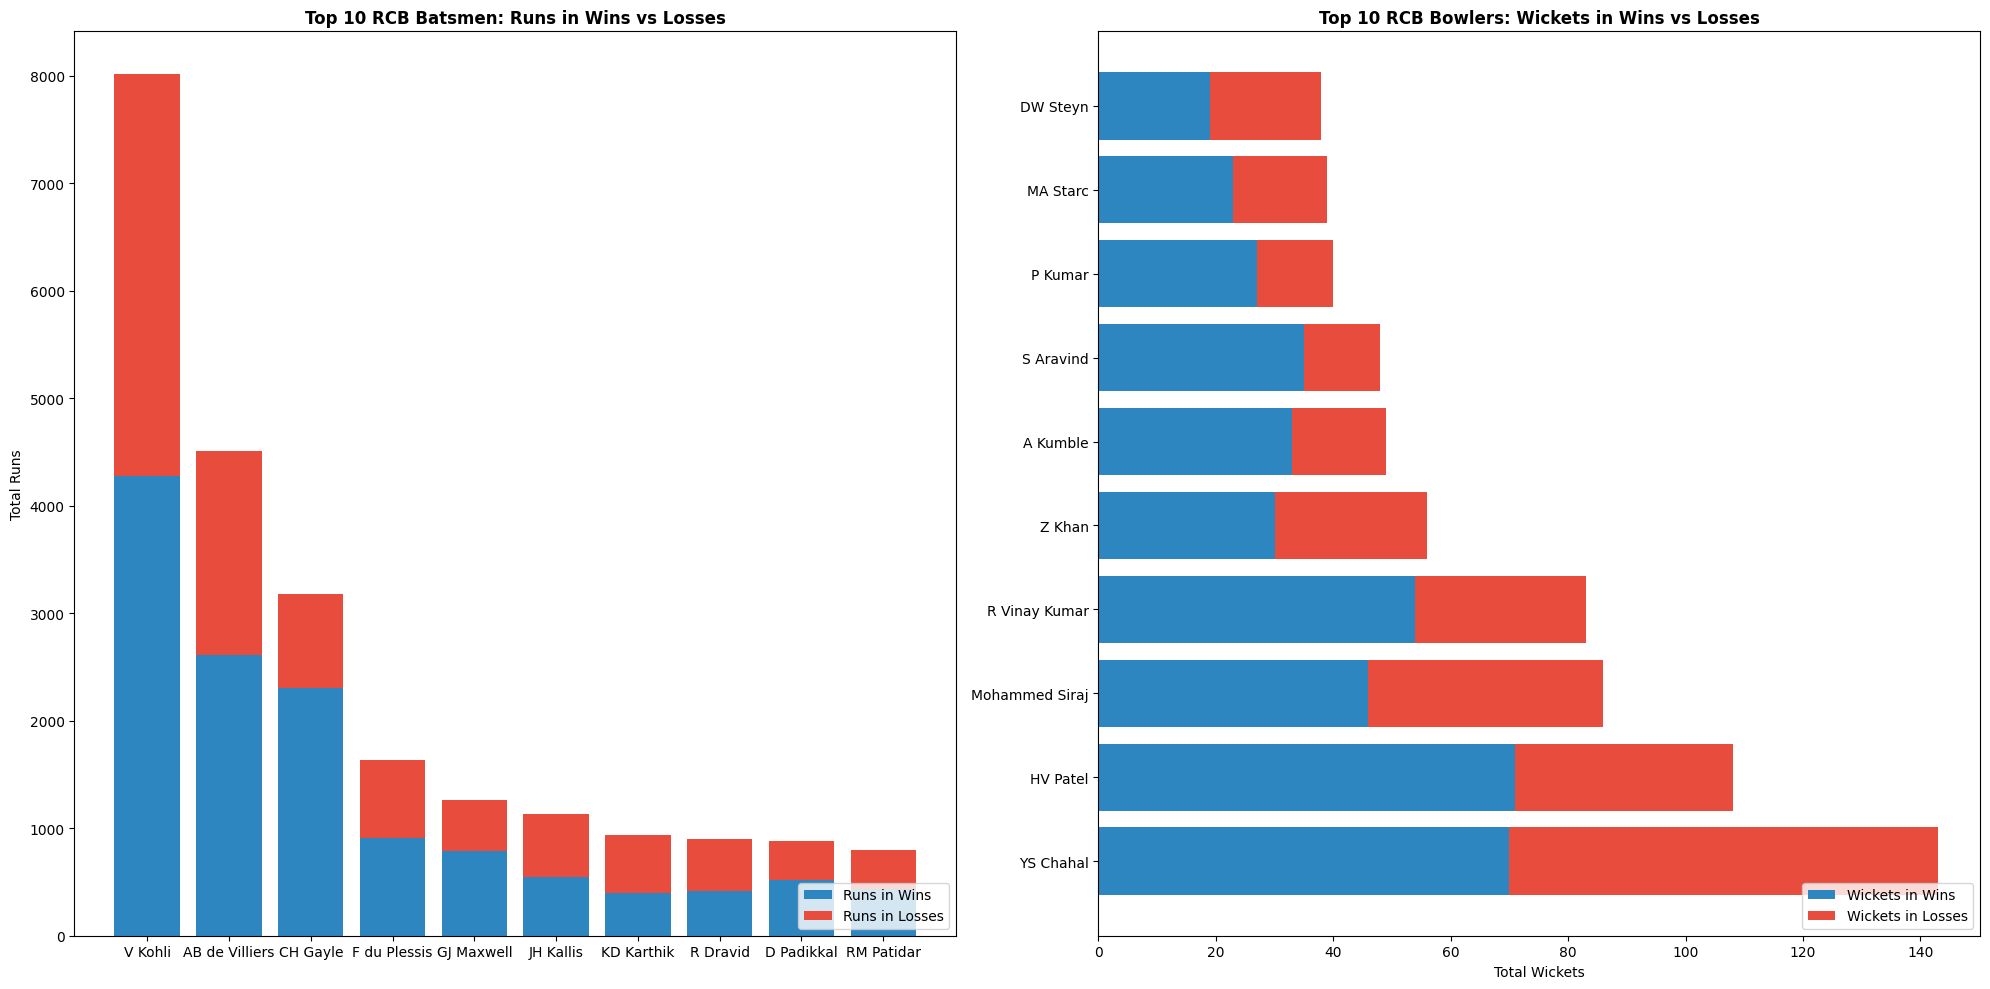

In [20]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Batsmen chart
batsmen = top_batsmen.index
runs_wins = top_batsmen['Runs_in_Wins']
runs_losses = top_batsmen['Runs_in_Losses']

x_pos = np.arange(len(batsmen))


ax1.bar(x_pos, runs_wins, color='#2E86C1', label='Runs in Wins')
ax1.bar(x_pos, runs_losses, bottom=runs_wins, color='#E74C3C', label='Runs in Losses')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(batsmen)
ax1.set_title('Top 10 RCB Batsmen: Runs in Wins vs Losses', fontweight='bold')
ax1.set_ylabel('Total Runs')
ax1.legend(loc='lower right')


# Bowlers chart
bowlers = top_bowlers.index
wkts_wins = top_bowlers['wickets_in_Wins']
wkts_losses = top_bowlers['wickets_in_Losses']

y_pos = np.arange(len(bowlers))

ax2.barh(y_pos, wkts_wins, color='#2E86C1', label='Wickets in Wins')
ax2.barh(y_pos, wkts_losses, left=wkts_wins, color='#E74C3C', label='Wickets in Losses')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(bowlers)
ax2.set_title('Top 10 RCB Bowlers: Wickets in Wins vs Losses', fontweight='bold')
ax2.set_xlabel('Total Wickets')
ax2.legend(loc='lower right')

plt.savefig(r"H:\project1\top_10_rcb_players",dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()


## Day 5 Summary: Player MVP Analysis

Key Findings — Batsmen
- **Virat Kohli** leads with 8,014 total runs — 53.4% coming in wins
- **Chris Gayle** has the highest win% contribution (72.5% of his runs in RCB wins) — a true match-winner
- **AB de Villiers** scored 4,510 runs with 58% in wins — consistent performer
- **KD Karthik** has only 42% of runs in wins despite 937 total runs — scores heavily in losses

Key Findings — Bowlers
- **YS Chahal** leads with 143 total wickets (48.9% in wins)
- **S Aravind** has the highest win% (72.9%) — 35 of 48 wickets came in victories
- **HV Patel** took 65.7% of his 108 wickets in wins — RCB's most impactful bowler
- **A Kumble** (67.3%) and **R Vinay Kumar** (65.1%) also show strong win% contributions

Conclusion
Players like Chris Gayle and S Aravind perform disproportionately well in RCB victories — these are the true match-winners. Retention strategy should prioritize players whose performances correlate most with team success, not just raw volume.

### Project Complete
This concludes the 5-day RCB IPL Analysis project. See README for full executive summary.